# Learning the Logical Channel from Syndrome Information

This notebook demonstrates the full pipeline for learning logical error probabilities from circuit-level syndrome data.

**Pipeline:**
1. **Build code** — construct a CSS code (rotated surface code)
2. **Syndrome extraction** — build a noisy stim circuit, sample detector/observable outcomes, extract the DEM
3. **Benchmark** — compare sampled LEP (direct Monte Carlo decoding) vs predicted LEP (from syndrome-learned priors)

In [2]:
import numpy as np
from bposd.css import css_code
from sim_qec.codes_family.hpc_lp import rotated_surface_code_checks
from sim_qec.pipeline import (
    SyndromeExtractionConfig,
    run_syndrome_extraction,
    benchmark_lep,
)
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

## Step 1: Build the CSS Code

We use the rotated surface code of distance $d$, constructed via `rotated_surface_code_checks` and wrapped in `bposd.css.css_code`.

In [3]:
d = 3
Hx, Hz = rotated_surface_code_checks(d)
code = css_code(Hx, Hz)

print(f"Code: [[{code.N}, {code.K}, d={d}]]")
print(f"Hx shape: {code.hx.shape}, Hz shape: {code.hz.shape}")
print(f"CSS condition Hx @ Hz^T = 0: {np.all((code.hx @ code.hz.T) % 2 == 0)}")

Code: [[9, 1, d=3]]
Hx shape: (4, 9), Hz shape: (4, 9)
CSS condition Hx @ Hz^T = 0: True


## Step 2: Syndrome Extraction

Configure the circuit-level noise model and run the syndrome extraction experiment.
The `num_samples_true_lep` parameter controls how many fresh shots are used
in `benchmark_lep` to compute the ground-truth LEP.

In [4]:
config = SyndromeExtractionConfig(
    num_cycles=1,
    physical_error_rate=5e-4,
    shots=5_000_000,
    num_samples_true_lep=100_000_000,
    fault_type="DEPOLARIZE1",
    circuit_error_params=CircuitErrorParams(
        p_i=1.0,
        p_state_p=0.8,
        p_m=0.9,
        p_CX=0.0, # for d =3, we set p_CX = 0.0 since these in principle unlearnable in theory, but in practice we can still learn something from them with good approximation (See Section III.C). 
        p_idling_gate=0.0,
    ),
)

result = run_syndrome_extraction(code, config)

Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]


### Inspect the extraction result

In [5]:
print(f"Detectors:    {result.detector_error_model.num_detectors}")
print(f"Observables:  {result.detector_error_model.num_observables}")
print(f"Detector array shape:    {result.dem_vals.shape}")
print(f"Observable array shape:  {result.log_vals.shape}")
print(f"Check matrix shape:      {result.check_matrix.shape}")
print(f"Number of faults:        {len(result.true_priors)}")
print(f"Syndrome expectations:   {result.syndrome_expectations}")

Detectors:    8
Observables:  1
Detector array shape:    (5000000, 8)
Observable array shape:  (5000000, 1)
Check matrix shape:      (8, 19)
Number of faults:        19
Syndrome expectations:   [0.9941076 0.9934148 0.9971388 0.9971408 0.9823588 0.9829896 0.9891772
 0.9891988]


### Visualize the stim circuit (optional)

In [3]:
# print(result.circuit)

## Plot 2: LEP vs Physical Error Rate

Sweep physical error rate $p \in \{10^{-4},\, 3{\times}10^{-4},\, 6{\times}10^{-4},\, 10^{-3},\, 5{\times}10^{-3}\}$.
For each $p$, use $\text{shots} = \lfloor 10/p \rfloor$ and run 10 repetitions to get error bars.
The **true LEP** is computed once per $p$ from $10^8$ fresh samples.

In [8]:
from sim_qec.pipeline import SyndromeExtractionConfig, run_syndrome_extraction
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

p_values = [5e-5, 1e-4, 2e-4, 3e-4, 4e-4]
n_reps = 20
subsample_factor = 4

BPLSD_PARAMS = {
    'max_iter': 5, 'bp_method': 'min_sum', 'ms_scaling_factor': 0.5,
    'schedule': 'parallel', 'lsd_method': 'lsd_e', 'lsd_order': 3,
}

true_leps = []
sampled_leps = {p: [] for p in p_values}
predicted_leps = {p: [] for p in p_values}

for p in p_values:
    print(f'\n=== p = {p:.0e} ===')
    shots_per_rep = round(10 / p)

    # Build circuit once for this p
    config = SyndromeExtractionConfig(
        num_cycles=1,
        physical_error_rate=p,
        shots=shots_per_rep,
        fault_type='DEPOLARIZE1',
        circuit_error_params=CircuitErrorParams(
            p_i=1.0, p_state_p=0.8, p_m=0.9, p_CX=1.0, p_idling_gate=0.0,
        ),
    )
    res = run_syndrome_extraction(code, config)
    h = res.check_matrix
    l = res.observables_matrix
    true_priors_p = res.true_priors

    # Set up decoder once for this p
    decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS)
    decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors_p})

    # --- Method 1: True LEP from analytical enumeration (fast) ---
    dummy_predictor = PredictPriors(dectector_samples=res.dem_vals, check_matrix=h, subsample=True, subsample_factor=subsample_factor)
    t_lep = dummy_predictor.predict_logical_error_efficient(
        decoder=decoder, observables_matrix=l, priors=true_priors_p, max_order=4,
    )

    # # --- Method 2: True LEP from sampling (slow, uncomment to use) ---
    # num_samples_true = int(1e7)
    # dem_true, log_true = res.sampler.sample(shots=num_samples_true, separate_observables=True)
    # dem_true, log_true = dem_true.astype(int), log_true.astype(int)
    # corr_true = decoder.decode(dem_true)
    # t_lep = float(np.average(
    #     ((log_true + (corr_true @ l.T) % 2) % 2).any(axis=1).astype(int)
    # ))

    true_leps.append(t_lep)
    print(f'  True LEP: {t_lep:.4e}')

    # n_reps repetitions with shots = 10/p
    for rep in range(n_reps):
        dem_rep, log_rep = res.sampler.sample(shots=shots_per_rep, separate_observables=True)
        dem_rep = dem_rep.astype(int)
        log_rep = log_rep.astype(int)

        # Sampled LEP (decoder already set with true priors)
        corr = decoder.decode(dem_rep)
        les = ((log_rep + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
        sampled_leps[p].append(float(np.average(les)))

        # Predicted LEP (learn priors from this rep's syndromes)
        predictor = PredictPriors(dectector_samples=dem_rep, check_matrix=h, subsample=True, subsample_factor=subsample_factor)
        A_syn, stabs = predictor._build_A_matrix_syndromes()
        stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
        pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
        lep_p = predictor.predict_logical_error_efficient(
            decoder=decoder, observables_matrix=l, priors=pred_priors, max_order=4,
        )
        predicted_leps[p].append(lep_p)

    s_arr = np.array(sampled_leps[p])
    p_arr = np.array(predicted_leps[p])
    print(f'  Sampled LEP:   {s_arr.mean():.4e} +/- {s_arr.std():.4e}')
    print(f'  Predicted LEP: {p_arr.mean():.4e} +/- {p_arr.std():.4e}')

print('\nDone.')


=== p = 5e-05 ===
Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]
  True LEP: 2.1208e-06
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape i

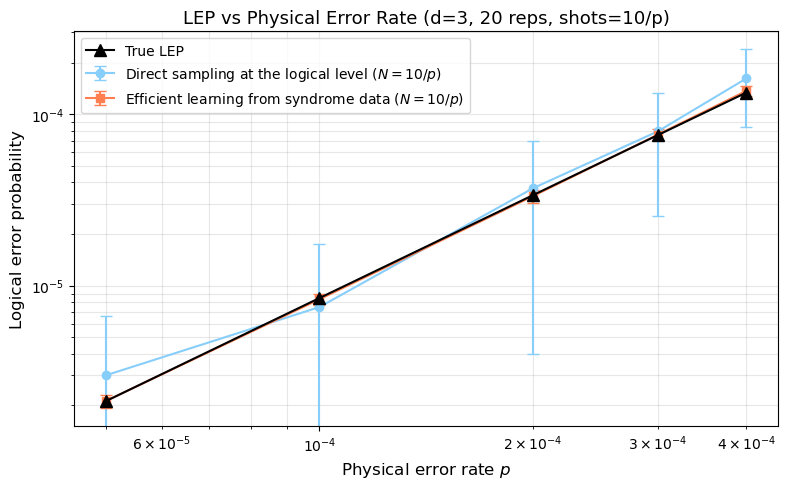

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# True LEP
ax.plot(p_values, true_leps, 'k^-', ms=8, lw=1.5, label='True LEP', zorder=3)

# Direct sampling at the logical level
s_means = [np.mean(sampled_leps[p]) for p in p_values]
s_stds = [np.std(sampled_leps[p]) for p in p_values]
ax.errorbar(p_values, s_means, yerr=s_stds, fmt='o-', color='lightskyblue',
            capsize=4, ms=6, lw=1.5, label=r'Direct sampling at the logical level ($N=10/p$)')

# Efficient learning from syndrome data
p_means = [np.mean(predicted_leps[p]) for p in p_values]
p_stds = [np.std(predicted_leps[p]) for p in p_values]
ax.errorbar(p_values, p_means, yerr=p_stds, fmt='s-', color='coral',
            capsize=4, ms=6, lw=1.5, label=r'Efficient learning from syndrome data ($N=10/p$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=12)
ax.set_ylabel('Logical error probability', fontsize=12)
ax.set_title(f'LEP vs Physical Error Rate (d={d}, {n_reps} reps, shots=10/p)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Step 4: Sample Complexity — Minimum Shots for 10% Relative Precision

Fix $p = 5 \times 10^{-5}$ and compute the true LEP from $10^7$ sampled shots.
Then subsample at increasing $N$ and measure the relative error of both
the sampled LEP and predicted LEP against this ground truth.

In [10]:
from sim_qec.pipeline import SyndromeExtractionConfig, run_syndrome_extraction
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

p_fixed = 5e-5
subsample_factor = 4

BPLSD_PARAMS = {
    'max_iter': 5, 'bp_method': 'min_sum', 'ms_scaling_factor': 0.5,
    'schedule': 'parallel', 'lsd_method': 'lsd_e', 'lsd_order': 3,
}

# Build circuit at p = 5e-5
config_fixed = SyndromeExtractionConfig(
    num_cycles=1,
    physical_error_rate=p_fixed,
    shots=int(10 / p_fixed),
    fault_type='DEPOLARIZE1',
    circuit_error_params=CircuitErrorParams(
        p_i=1.0, p_state_p=0.8, p_m=0.9, p_CX=1.0, p_idling_gate=0.0,
    ),
)
res_fixed = run_syndrome_extraction(code, config_fixed)
h = res_fixed.check_matrix
l = res_fixed.observables_matrix
true_priors_fixed = res_fixed.true_priors

# Set up decoder
decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS)
decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors_fixed})

# True LEP from 1e7 sampled shots
num_samples_true = int(1e7)
dem_true, log_true = res_fixed.sampler.sample(shots=num_samples_true, separate_observables=True)
dem_true, log_true = dem_true.astype(int), log_true.astype(int)
corr_true = decoder.decode(dem_true)
true_lep_fixed = float(np.average(
    ((log_true + (corr_true @ l.T) % 2) % 2).any(axis=1).astype(int)
))
print(f'True LEP (from {num_samples_true:,} shots): {true_lep_fixed:.6e}')

# Subsample at increasing N
sample_sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000,
                500_000, 1_000_000, 5_000_000]

results_sampled = []   # (N, lep, relative_error)
results_predicted = [] # (N, lep, relative_error)

for N in sample_sizes:
    # Fresh samples at this N
    dem_sub, log_sub = res_fixed.sampler.sample(shots=N, separate_observables=True)
    dem_sub, log_sub = dem_sub.astype(int), log_sub.astype(int)

    # Sampled LEP
    corr = decoder.decode(dem_sub)
    les = ((log_sub + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
    lep_s = float(np.average(les))
    rel_err_s = abs(lep_s - true_lep_fixed) / true_lep_fixed if true_lep_fixed > 0 else np.inf
    results_sampled.append((N, lep_s, rel_err_s))

    # Predicted LEP
    predictor = PredictPriors(dectector_samples=dem_sub, check_matrix=h, subsample=True, subsample_factor=subsample_factor)
    A_syn, stabs = predictor._build_A_matrix_syndromes()
    stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
    pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
    lep_p = predictor.predict_logical_error_efficient(
        decoder=decoder, observables_matrix=l, priors=pred_priors, max_order=4,
    )
    rel_err_p = abs(lep_p - true_lep_fixed) / true_lep_fixed if true_lep_fixed > 0 else np.inf
    results_predicted.append((N, lep_p, rel_err_p))

    print(f'N={N:>11,}  |  sampled LEP={lep_s:.4e} (err={rel_err_s:.1%})  '
          f'|  predicted LEP={lep_p:.4e} (err={rel_err_p:.1%})')

Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]
True LEP (from 10,000,000 shots): 2.400000e-06
the detector shape is: (1000, 8)
N=      1,000  |  sampled LEP=0.0000e+00 (err=100.0%)  |  predicted LEP=5.0000e-300 (err=100.0%)
the detector shape is: (5000, 8)
N=      5,000  |  sampled LEP=1.0000e-03 (err=41566.7%)  |  predicted LEP=1.0011e-03 (err=41612.3%)
the detector shape is: (10000, 8)
N=     10,000  |  sampled LEP=8.0000e-04 (err=33233.3%)  |  predicted LEP=3.0934e-06 (err=28.9%)
the detector shape is: (50000, 8)
N=     

### Minimum samples for 10% relative precision

In [11]:
threshold = 0.10  # 10% relative error

N_star_sampled = None
for N, _, rel_err in results_sampled:
    if rel_err <= threshold:
        N_star_sampled = N
        break

N_star_predicted = None
for N, _, rel_err in results_predicted:
    if rel_err <= threshold:
        N_star_predicted = N
        break

print(f'True LEP = {true_lep_fixed:.4e}  (p = {p_fixed:.0e})')
print(f'Minimum shots for \u226410% relative error:')
print(f'  Sampled LEP:   N* = {N_star_sampled:,}' if N_star_sampled else '  Sampled LEP:   not reached')
print(f'  Predicted LEP: N* = {N_star_predicted:,}' if N_star_predicted else '  Predicted LEP: not reached')

True LEP = 2.4000e-06  (p = 5e-05)
Minimum shots for ≤10% relative error:
  Sampled LEP:   N* = 5,000,000
  Predicted LEP: N* = 50,000


### Convergence plot

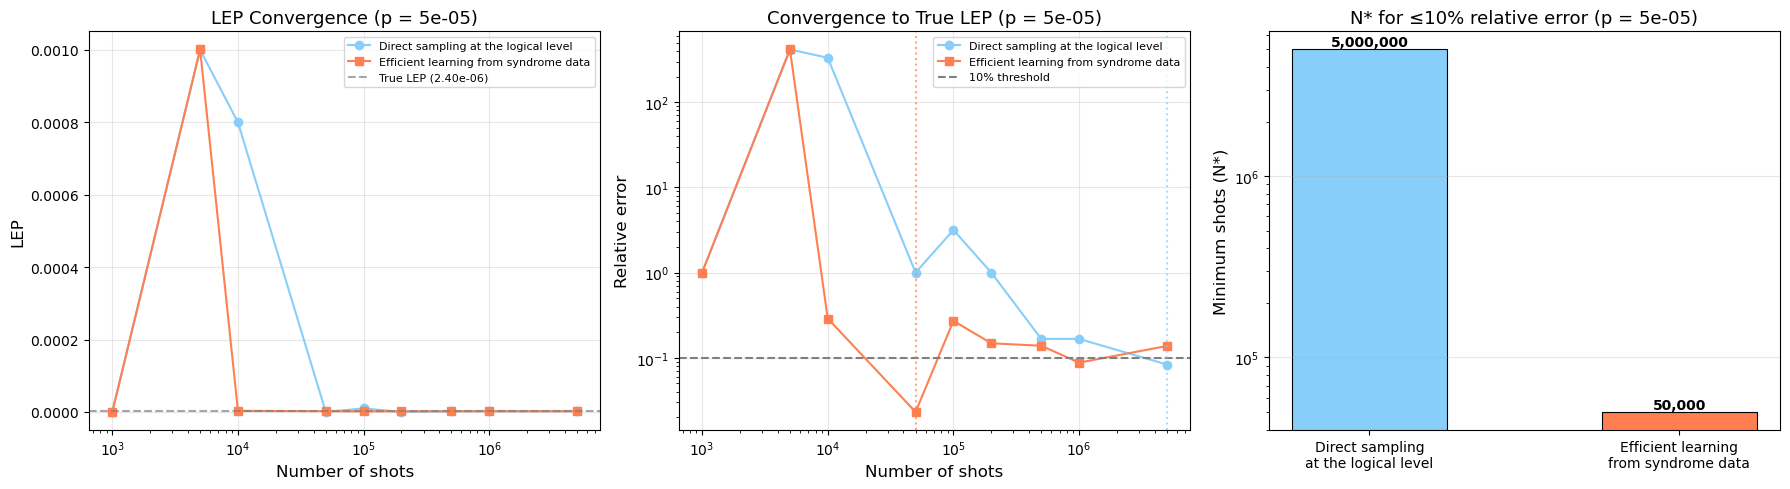

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Ns = [r[0] for r in results_sampled]

# --- Left: LEP vs sample size ---
ax = axes[0]
ax.plot(Ns, [r[1] for r in results_sampled], 'o-', color='lightskyblue', lw=1.5,
        label='Direct sampling at the logical level')
ax.plot(Ns, [r[1] for r in results_predicted], 's-', color='coral', lw=1.5,
        label='Efficient learning from syndrome data')
ax.axhline(true_lep_fixed, ls='--', color='gray', alpha=0.7,
           label=f'True LEP ({true_lep_fixed:.2e})')
ax.set_xscale('log')
ax.set_xlabel('Number of shots', fontsize=12)
ax.set_ylabel('LEP', fontsize=12)
ax.set_title(f'LEP Convergence (p = {p_fixed:.0e})', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Middle: Relative error vs sample size ---
ax = axes[1]
ax.plot(Ns, [r[2] for r in results_sampled], 'o-', color='lightskyblue', lw=1.5,
        label='Direct sampling at the logical level')
ax.plot(Ns, [r[2] for r in results_predicted], 's-', color='coral', lw=1.5,
        label='Efficient learning from syndrome data')
ax.axhline(threshold, ls='--', color='gray', lw=1.5, label='10% threshold')
if N_star_sampled:
    ax.axvline(N_star_sampled, ls=':', color='lightskyblue', alpha=0.7)
if N_star_predicted:
    ax.axvline(N_star_predicted, ls=':', color='coral', alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of shots', fontsize=12)
ax.set_ylabel('Relative error', fontsize=12)
ax.set_title(f'Convergence to True LEP (p = {p_fixed:.0e})', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: Histogram of N* ---
ax = axes[2]
methods = []
n_stars = []
colors = []
if N_star_sampled:
    methods.append('Direct sampling\nat the logical level')
    n_stars.append(N_star_sampled)
    colors.append('lightskyblue')
else:
    methods.append('Direct sampling\nat the logical level')
    n_stars.append(0)
    colors.append('lightskyblue')
if N_star_predicted:
    methods.append('Efficient learning\nfrom syndrome data')
    n_stars.append(N_star_predicted)
    colors.append('coral')
else:
    methods.append('Efficient learning\nfrom syndrome data')
    n_stars.append(0)
    colors.append('coral')

bars = ax.bar(methods, n_stars, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, n_stars):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, 0.01,
                'N/A', ha='center', va='bottom', fontsize=10, color='gray')
ax.set_ylabel('Minimum shots (N*)', fontsize=12)
ax.set_title(f'N* for \u226410% relative error (p = {p_fixed:.0e})', fontsize=13)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()